# Supplement 3 — Wind Turbine SCADA: when DBSCAN genuinely breaks

### DBSCAN lecture series · unsupervised learning with scikit-learn

**Companion to the main lecture notebook.** This one is about the failure mode.

> ### The lesson of this notebook
> The main lecture named DBSCAN's structural weakness — a single global ε cannot serve
> clusters of different density — and moved on. A wind turbine's power curve is where you
> actually meet it, because wind speed follows a Weibull distribution: the machine spends
> hundreds of hours at 7 m/s and a handful at 18 m/s. We show the failure, diagnose it
> numerically, try the textbook remedy (HDBSCAN), and then apply the fix that actually works:
> **remove the deterministic physics and cluster the residual.**
>
> A varying-density failure is usually not a reason to abandon density clustering. It is a
> signal that you are clustering in the wrong space.

---

### The asset

One 2 MW pitch-regulated turbine. The SCADA system records 10-minute averages of wind speed,
active power, rotor speed and blade pitch angle. A year of data, no labels.

The manufacturer's **power curve** defines normal behaviour:

| region | wind speed | behaviour |
|---|---|---|
| below cut-in | $v < 3.5$ m/s | parked, blades feathered to ~88°, no power |
| region 2 | $3.5 \le v < 12.5$ | maximum power tracking, $P \propto v^3$, pitch ≈ 0° |
| region 3 | $12.5 \le v \le 25$ | rated power, pitch increases to shed excess energy |
| cut-out | $v > 25$ | shut down |

Hidden in the year are two genuine faults and one perfectly legitimate but unusual mode:

- **blade icing / soiling** — power 45–70 % of what the wind justifies (a *fault*);
- **anemometer fault** — the wind sensor reads near zero while the machine produces happily
  (a *sensor* fault, not a turbine fault);
- **grid curtailment** — the network operator caps output at 800 kW (**not** a fault, but it
  looks like one, and confusing the two is a classic false-alarm generator).

### Learning objectives

- recognise a **varying-density** dataset, and measure the density gradient rather than
  guessing at it;
- see concretely why *no* choice of ε works, by trading off false alarms against missed faults;
- evaluate **HDBSCAN** as the textbook remedy, and see how far it gets;
- apply the **physics-informed feature transform** that makes the density uniform;
- distinguish an *anomaly* from an *undiscovered operating mode* — and know why DBSCAN
  putting a fault in its own cluster is informative, not a bug.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans, HDBSCAN
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                             precision_score, recall_score)

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3,
                     "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = ["#2563eb", "#f59e0b", "#10b981", "#8b5cf6", "#0891b2", "#ec4899"]
NOISE_C = "#dc2626"
RANDOM_STATE = 31

import sklearn
print("scikit-learn", sklearn.__version__)

scikit-learn 1.8.0


In [2]:
def k_distance(X, k):
    """Sorted distance from each point to its k-th nearest neighbour."""
    d, _ = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X)
    return np.sort(d[:, -1])


def plot_k_distance(X, k, eps=None, ax=None, title=None):
    kd = k_distance(X, k)
    ax = ax or plt.subplots(figsize=(7.5, 4.2))[1]
    ax.plot(kd, lw=2.2, color="#2563eb")
    if eps is not None:
        ax.axhline(eps, color=NOISE_C, ls="--", lw=1.6)
        ax.text(0.02 * len(kd), eps * 1.06, f"chosen eps = {eps}", color=NOISE_C, fontweight="bold")
    ax.set_xlabel("points sorted by k-distance")
    ax.set_ylabel(f"{k}-NN distance (standardised units)")
    ax.set_title(title or f"Sorted {k}-distance plot", fontweight="bold")
    return ax


def cluster_report(X, labels, truth=None, healthy_mask=None):
    """Standard summary: cluster count, noise rate, silhouette, and -- when ground
    truth is available -- regime ARI plus anomaly precision/recall."""
    m = labels != -1
    out = {"n_clusters": len(set(labels) - {-1}),
           "n_noise": int((~m).sum()),
           "noise_pct": round(100 * (~m).mean(), 1)}
    if len(set(labels[m])) > 1:
        out["silhouette"] = round(silhouette_score(X[m], labels[m]), 3)
    if truth is not None and healthy_mask is not None:
        h = healthy_mask
        if (h & m).sum() and len(set(labels[h & m])) > 1:
            out["ARI_regimes"] = round(adjusted_rand_score(truth[h & m], labels[h & m]), 3)
        out["anomaly_precision"] = round(precision_score(~h, ~m, zero_division=0), 3)
        out["anomaly_recall"] = round(recall_score(~h, ~m, zero_division=0), 3)
    return out


def scatter_labels(ax, XY, labels, title="", s=20, legend=True, names=None):
    for k in sorted(set(labels) - {-1}):
        sel = labels == k
        lbl = (names or {}).get(k, f"cluster {k}")
        ax.scatter(*XY[sel].T, s=s, c=PALETTE[k % len(PALETTE)], ec="none", alpha=.85,
                   label=f"{lbl}  (n={sel.sum()})")
    sel = labels == -1
    if sel.any():
        ax.scatter(*XY[sel].T, s=s * 4, c=NOISE_C, marker="X", ec="white", lw=.7, zorder=5,
                   label=f"noise, label = -1  (n={sel.sum()})")
    ax.set_title(title, fontweight="bold")
    if legend:
        ax.legend(fontsize=9)
    return ax

---
# 1. A year of SCADA data

In [3]:
RATED_KW, CUT_IN, RATED_V, CUT_OUT = 2000.0, 3.5, 12.5, 25.0


def ideal_power(v):
    """Manufacturer power curve [kW]."""
    p = np.zeros_like(v)
    r2 = (v >= CUT_IN) & (v < RATED_V)
    p[r2] = RATED_KW * ((v[r2] - CUT_IN) / (RATED_V - CUT_IN)) ** 3
    p[(v >= RATED_V) & (v <= CUT_OUT)] = RATED_KW
    return p


def ideal_rpm(v):
    r = np.clip(6.0 + 1.05 * (v - CUT_IN), 0, 16.5)
    r[v < CUT_IN] = 0.0
    return r


def ideal_pitch(v):
    pi = np.zeros_like(v)
    pi[v < CUT_IN] = 88.0                                  # feathered when parked
    hi = v > RATED_V
    pi[hi] = np.clip(1.8 * (v[hi] - RATED_V) ** 0.85, 0, 28)
    return pi

In [4]:
def make_year(seed=RANDOM_STATE, n=1400):
    """One year of 10-minute SCADA records from a 2 MW turbine."""
    rng = np.random.default_rng(seed)

    v = np.clip(rng.weibull(2.0, n) * 8.6, 0.2, 27.0)      # Weibull site wind distribution
    p = ideal_power(v) * rng.normal(1.0, 0.035, n)
    r = ideal_rpm(v) * rng.normal(1.0, 0.02, n)
    pitch = ideal_pitch(v) + rng.normal(0, 0.5, n)
    p[v > CUT_OUT] = 0.0; r[v > CUT_OUT] = 0.0; pitch[v > CUT_OUT] = 88.0

    state = np.array(["normal"] * n, dtype=object)
    state[v < CUT_IN] = "idle_below_cutin"

    # grid curtailment -- legitimate, but capped at 800 kW in the rated region
    idx = rng.choice(np.where((v > 13.0) & (v < 20))[0], 80, replace=False)
    p[idx] = 800.0 * rng.normal(1.0, 0.03, len(idx))
    r[idx] = 11.5 * rng.normal(1.0, 0.02, len(idx))
    pitch[idx] = 9.5 + rng.normal(0, 0.8, len(idx))
    state[idx] = "curtailed"

    # blade icing / soiling -- a genuine fault
    pool = np.where((v > 5.5) & (v < 11.5) & (state == "normal"))[0]
    idx = rng.choice(pool, 34, replace=False)
    p[idx] = ideal_power(v[idx]) * rng.uniform(0.45, 0.70, len(idx))
    r[idx] = ideal_rpm(v[idx]) * rng.uniform(0.80, 0.92, len(idx))
    state[idx] = "icing_underperformance"

    # anemometer fault -- the wind sensor reads near zero, the machine runs on
    pool = np.where((v > 8) & (state == "normal"))[0]
    idx = rng.choice(pool, 15, replace=False)
    v[idx] = rng.uniform(0.3, 1.4, len(idx))
    state[idx] = "anemometer_fault"

    df = pd.DataFrame({"wind_speed_ms": v, "active_power_kw": p,
                       "rotor_rpm": r, "pitch_angle_deg": pitch})
    df["true_state"] = state                                # for SCORING ONLY
    df["day"] = np.sort(rng.uniform(0, 365, n)).round(1)
    return df.round(3)


FEATURES = ["wind_speed_ms", "active_power_kw", "rotor_rpm", "pitch_angle_deg"]
df = make_year()
faulty = df.true_state.isin(["icing_underperformance", "anemometer_fault"]).values
print(df.shape)
df.true_state.value_counts()

(1400, 6)


true_state
normal                    1052
idle_below_cutin           219
curtailed                   80
icing_underperformance      34
anemometer_fault            15
Name: count, dtype: int64

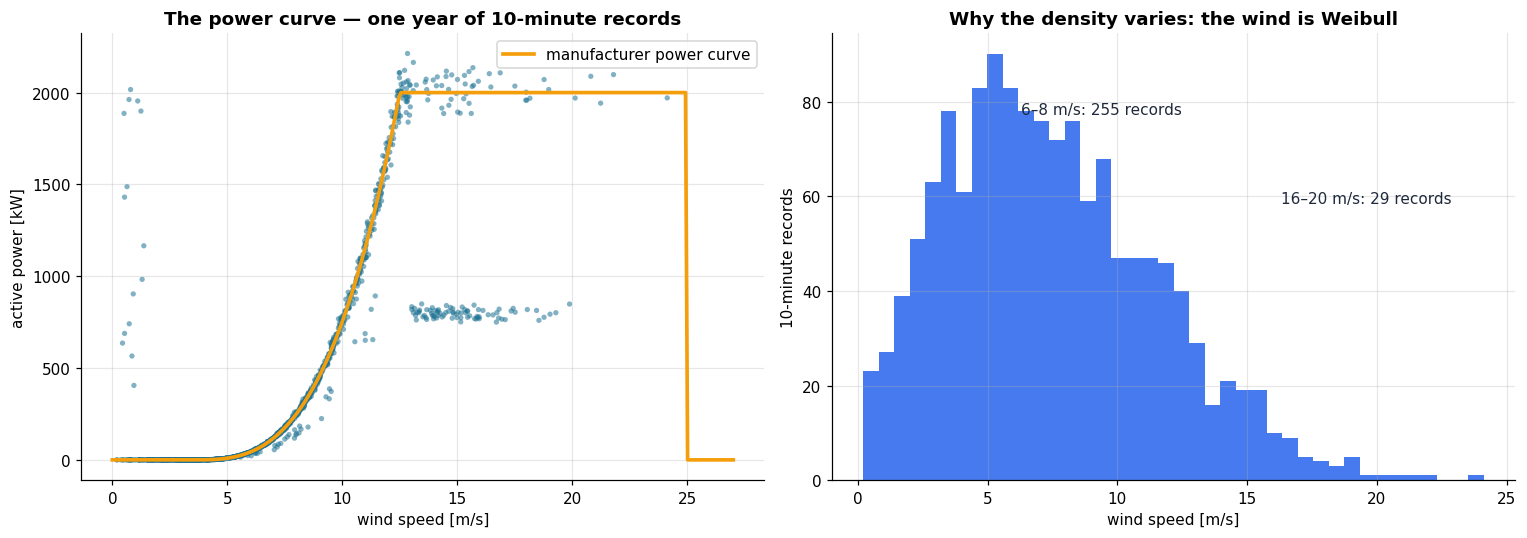

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(df.wind_speed_ms, df.active_power_kw, s=12, c="#1C7293", alpha=.55, ec="none")
vv = np.linspace(0, 27, 300)
ax.plot(vv, ideal_power(vv), color="#f59e0b", lw=2.4, label="manufacturer power curve")
ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel("active power [kW]")
ax.set_title("The power curve — one year of 10-minute records", fontweight="bold")
ax.legend()

ax = axes[1]
ax.hist(df.wind_speed_ms, bins=40, color="#2563eb", alpha=.85)
ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel("10-minute records")
ax.set_title("Why the density varies: the wind is Weibull", fontweight="bold")
for lo, hi in [(6, 8), (16, 20)]:
    k = int(((df.wind_speed_ms >= lo) & (df.wind_speed_ms < hi)).sum())
    ax.text(lo + 0.3, ax.get_ylim()[1] * (0.82 if lo == 6 else 0.62),
            f"{lo}–{hi} m/s: {k} records", fontsize=10, color="#1e293b")
fig.tight_layout(); plt.show()

The left plot is the whole problem in one picture. The healthy data is not a set of blobs —
it is a **one-dimensional curve** with scatter around it, and points are packed densely along
the middle of that curve and sparsely at its right-hand end.

The right plot says why: wind speed is Weibull-distributed. Roughly ten times as many records
fall between 6 and 8 m/s as between 16 and 20 m/s. That is not a quirk of the simulation —
it is the wind resource at essentially every site on earth.

---
# 2. The naive attempt

Standardise the four channels and run DBSCAN, exactly as in the main lecture.

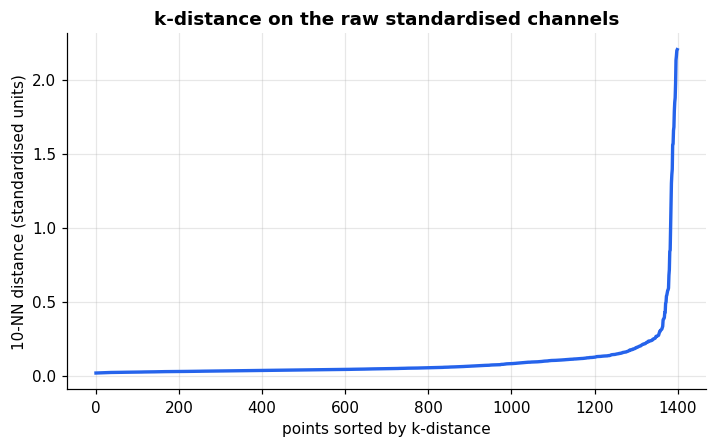

percentiles: {50: 0.047, 80: 0.105, 90: 0.149, 95: 0.227, 97: 0.3, 99: 1.3}


In [6]:
X = StandardScaler().fit_transform(df[FEATURES].values)
MIN_SAMPLES = 10

plot_k_distance(X, MIN_SAMPLES, title="k-distance on the raw standardised channels")
plt.show()

kd = k_distance(X, MIN_SAMPLES)
print("percentiles:", {p: round(float(np.percentile(kd, p)), 3) for p in (50, 80, 90, 95, 97, 99)})

There is no knee here — the curve bends continuously. That is the first symptom of varying
density: a knee exists only when there is one characteristic scale, and here there are many.

Let us fit anyway, across a range of ε, and score two things that matter operationally:

- **icing recall** — how many of the 34 genuine underperformance events we catch;
- **healthy high-wind records wrongly flagged** — perfectly normal production above 14 m/s
  that we would be sending an engineer to investigate.

In [7]:
hi_wind = (df.wind_speed_ms > 14).values
rows = []
for eps in [0.10, 0.15, 0.20, 0.25, 0.30, 0.45]:
    lb = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(X)
    flagged = lb == -1
    rows.append({
        "eps": eps,
        "clusters": len(set(lb) - {-1}),
        "flagged": int(flagged.sum()),
        "icing_recall": round(float(flagged[df.true_state.values == "icing_underperformance"].mean()), 2),
        "healthy_highwind_flagged": int((flagged & hi_wind & ~faulty).sum()),
    })
pd.DataFrame(rows).set_index("eps")

,clusters,flagged,icing_recall,healthy_highwind_flagged
eps,,,,
0.10,8,170,0.94,67
0.15,3,95,0.53,54
0.20,3,49,0.32,22
0.25,3,37,0.12,18
0.30,3,30,0.00,15
0.45,3,20,0.00,5


Read the last two columns together — they are the two sides of one dial:

- at **ε = 0.10** we catch 94 % of the icing, and flag **67** healthy high-wind records;
- at **ε = 0.30** we flag only 15 healthy records, and catch **none** of the icing;
- nowhere in between is there a setting that is acceptable on both counts.

This is not bad luck with the grid. It is structural, and we can show exactly why.

## 2.1 Diagnosing it: measure the density gradient

The local density around a point is what DBSCAN thresholds with ε. So measure it directly —
the k-nearest-neighbour distance is a standard inverse density estimate — and plot it against
wind speed.

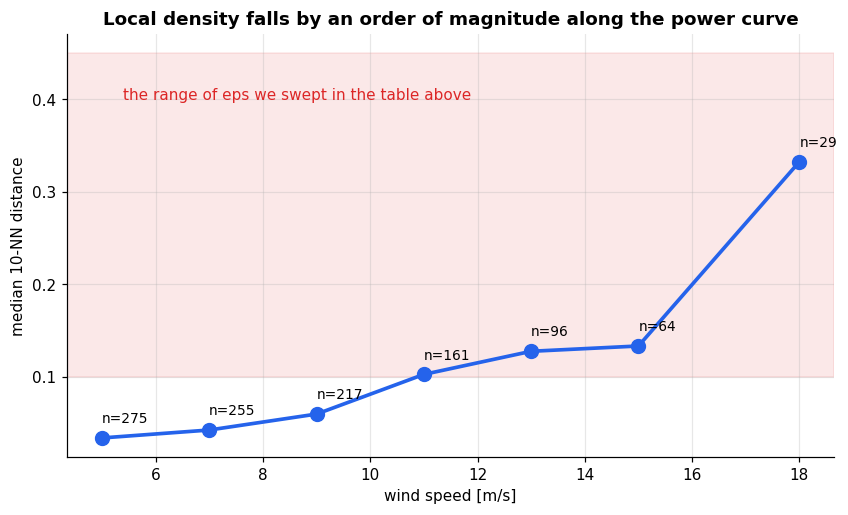

median 10-NN distance at 4-6 m/s   : 0.034
median 10-NN distance at 16-20 m/s : 0.332
ratio                              : 9.8x


In [8]:
k10 = NearestNeighbors(n_neighbors=MIN_SAMPLES + 1).fit(X).kneighbors(X)[0][:, -1]

bins = [(4, 6), (6, 8), (8, 10), (10, 12), (12, 14), (14, 16), (16, 20)]
centres, med, counts = [], [], []
for lo, hi in bins:
    sel = (df.wind_speed_ms >= lo) & (df.wind_speed_ms < hi)
    centres.append((lo + hi) / 2); med.append(np.median(k10[sel])); counts.append(int(sel.sum()))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(centres, med, "o-", lw=2.4, ms=9, color="#2563eb")
for c, m, k in zip(centres, med, counts):
    ax.annotate(f"n={k}", (c, m), textcoords="offset points", xytext=(0, 10), fontsize=9)
ax.axhspan(0.10, 0.45, color="#dc2626", alpha=.10)
ax.text(5.4, 0.40, "the range of eps we swept in the table above",
        color=NOISE_C, fontsize=10)
ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel(f"median {MIN_SAMPLES}-NN distance")
ax.set_title("Local density falls by an order of magnitude along the power curve",
             fontweight="bold")
plt.show()

print(f"median 10-NN distance at 4-6 m/s   : {med[0]:.3f}")
print(f"median 10-NN distance at 16-20 m/s : {med[-1]:.3f}")
print(f"ratio                              : {med[-1] / med[0]:.1f}x")

**A factor of about ten.** Any ε small enough to resolve structure in the dense mid-curve is
far below the typical neighbour distance at high wind, so every high-wind record fails the
MinPts test and is labelled noise. Any ε large enough to accept high-wind records swallows the
icing events, which sit only modestly below a densely populated curve.

The shaded band is the ε range we swept. Almost all of it sits *below* the median neighbour
distance at 16–20 m/s (0.33), which is precisely why healthy high-wind records were flagged at
nearly every setting — and by the time ε is finally large enough to accept them (0.45), it is
far too large to notice the icing, which is why recall there is zero.

---
# 3. The textbook remedy: HDBSCAN

This is the situation HDBSCAN is built for. Rather than one global ε, it builds a hierarchy
over all density levels and extracts clusters that persist across scales. It needs no ε at
all — only `min_cluster_size`.

In [9]:
rows = []
for mcs in [15, 20, 25, 40]:
    h = HDBSCAN(min_cluster_size=mcs, copy=True).fit_predict(X)
    flagged = h == -1
    rows.append({
        "min_cluster_size": mcs,
        "clusters": len(set(h) - {-1}),
        "flagged": int(flagged.sum()),
        "icing_recall": round(float(flagged[df.true_state.values == "icing_underperformance"].mean()), 2),
        "healthy_highwind_flagged": int((flagged & hi_wind & ~faulty).sum()),
    })
pd.DataFrame(rows).set_index("min_cluster_size")

,clusters,flagged,icing_recall,healthy_highwind_flagged
min_cluster_size,,,,
15,3,28,0.00,13
20,5,178,0.88,47
25,5,175,0.82,47
40,4,112,0.38,51


Compare these against §2 **at a matched alarm budget**, which is the only fair way:

| method | records flagged | icing recall | healthy high-wind flagged |
|---|---|---|---|
| DBSCAN, ε = 0.10 | 170 | **0.94** | 67 |
| HDBSCAN, `min_cluster_size` = 20 | 178 | 0.88 | 47 |
| DBSCAN, ε = 0.20 | 49 | 0.32 | 22 |
| HDBSCAN, `min_cluster_size` = 15 | 28 | **0.00** | 13 |

HDBSCAN is **not** rescuing us. For a similar number of alarms it catches slightly *fewer*
icing events than DBSCAN does, and at a small alarm budget it catches none at all. It flags
somewhat fewer healthy high-wind records, which is a genuine if modest gain — but the shape of
the trade-off is unchanged.

That result is worth taking seriously rather than explaining away. HDBSCAN removes the
single-global-ε constraint, and the single-global-ε constraint was **not** the whole problem.
The deeper issue is that the healthy data is a **one-dimensional curve**, not a set of blobs.
Density-based clustering looks for dense regions separated by sparse valleys; along a smooth
power curve there are no valleys to find, only a density that tapers toward the end. No
hierarchical treatment of density levels can invent structure that is not there.

Changing the algorithm did not fix it, because the problem was never in the algorithm.

---
# 4. The fix: cluster the residual, not the raw signal

Here is the move that matters, and it is the standard method in wind-farm performance
monitoring. Almost all the variance in the raw channels is *deterministic*: given the wind
speed, the power curve tells you what the power, rotor speed and pitch **should** be. That
deterministic part is exactly what stretches the data into a curve and makes its density
uneven.

So divide it out. For each record, compare what the machine did against what the power curve
says it should have done at that wind speed:

$$\text{power deficit} = \frac{P_{\text{ideal}}(v) - P_{\text{measured}}}{\max\!\left(P_{\text{ideal}}(v),\,100\right)}
\qquad
\text{rpm ratio} = \frac{\omega_{\text{measured}}}{\max\!\left(\omega_{\text{ideal}}(v),\,1\right)}
\qquad
\text{pitch deviation} = \theta_{\text{measured}} - \theta_{\text{ideal}}(v)$$

The floors in the denominators keep things finite near cut-in, where the ideal values go to
zero. Note what these three features are: **normalised, dimensionless deviations from expected
behaviour**. A healthy record sits at (0, 1, 0) whether the wind is 5 m/s or 20 m/s — the
wind-speed dependence has been divided out, and with it the density gradient.

In [10]:
v = df.wind_speed_ms.values
p_ref, r_ref, pi_ref = ideal_power(v), ideal_rpm(v), ideal_pitch(v)

df["power_deficit"] = np.clip((p_ref - df.active_power_kw.values) / np.maximum(p_ref, 100), -3, 1.2)
df["rpm_ratio"]     = np.clip(df.rotor_rpm.values / np.maximum(r_ref, 1.0), 0, 3)
df["pitch_dev"]     = df.pitch_angle_deg.values - pi_ref

RESIDUAL = ["power_deficit", "rpm_ratio", "pitch_dev"]
df.groupby("true_state")[RESIDUAL].agg(["mean", "std"]).round(3)

power_deficit        rpm_ratio        pitch_dev       
                                mean    std      mean    std      mean    std
true_state                                                                   
anemometer_fault              -3.000  0.000     3.000  0.000   -87.032  2.718
curtailed                      0.601  0.012     0.698  0.014     5.316  2.242
icing_underperformance         0.362  0.111     0.854  0.034     0.040  0.494
idle_below_cutin               0.000  0.000     0.000  0.000     0.040  0.531
normal                         0.001  0.028     1.001  0.021    -0.001  0.494

Read that table before clustering — the five states now occupy five clearly distinct places:

| state | power deficit | rpm ratio | pitch deviation |
|---|---|---|---|
| normal | ≈ 0 | ≈ 1 | ≈ 0 |
| idle below cut-in | 0 | 0 | ≈ 0 |
| curtailed | ≈ 0.60 | ≈ 0.70 | ≈ +5 |
| icing | ≈ 0.36 | ≈ 0.85 | ≈ 0 |
| anemometer fault | −3 (clipped) | 3 (clipped) | ≈ −87 |

The spreads are not equal — icing scatters about four times as widely in `power_deficit` as
normal operation does, and pitch deviation is noisier for the curtailed and anemometer groups.
What matters is that every spread is now small **relative to the gaps between the groups**,
because the wind-speed dependence that was stretching each group along a curve has been
divided out.

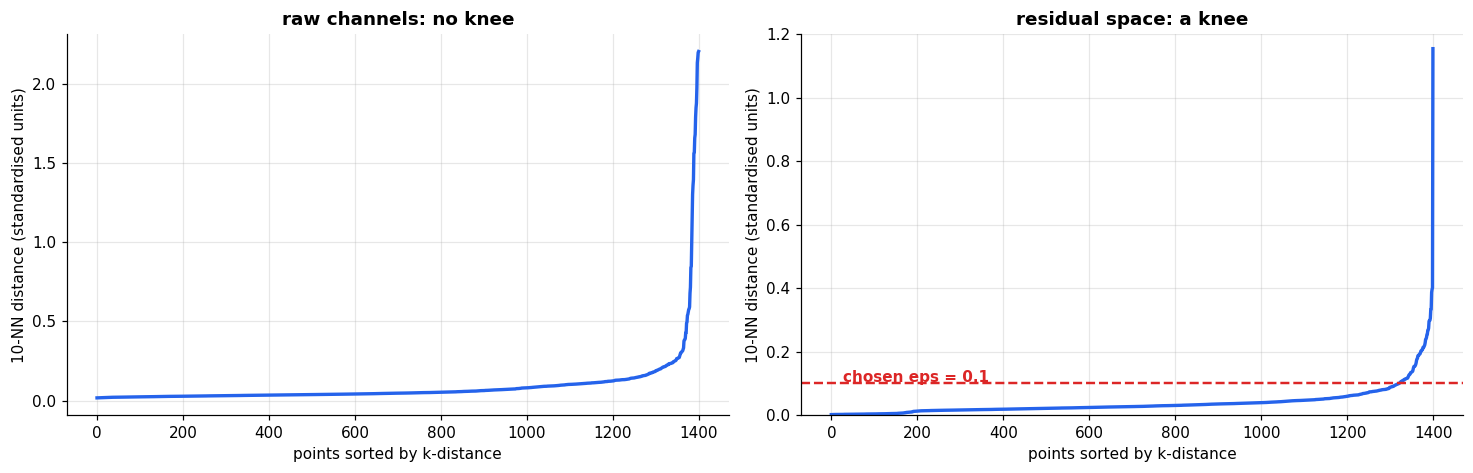

density gradient along the power curve
  raw channels    : 4-6 m/s 0.034   16-20 m/s 0.332   ratio   9.8x
  residual space  : 4-6 m/s 0.021   16-20 m/s 0.115   ratio   5.5x


In [11]:
Xr = StandardScaler().fit_transform(df[RESIDUAL].values)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
plot_k_distance(X, MIN_SAMPLES, ax=axes[0], title="raw channels: no knee")
plot_k_distance(Xr, MIN_SAMPLES, eps=0.10, ax=axes[1], title="residual space: a knee")
axes[1].set_ylim(0, 1.2)
fig.tight_layout(); plt.show()

k10r = NearestNeighbors(n_neighbors=MIN_SAMPLES + 1).fit(Xr).kneighbors(Xr)[0][:, -1]
print("density gradient along the power curve")
for tag, kk in [("raw channels    ", k10), ("residual space  ", k10r)]:
    lo = np.median(kk[(df.wind_speed_ms >= 4) & (df.wind_speed_ms < 6)])
    hi = np.median(kk[(df.wind_speed_ms >= 16) & (df.wind_speed_ms < 20)])
    print(f"  {tag}: 4-6 m/s {lo:.3f}   16-20 m/s {hi:.3f}   ratio {hi/lo:5.1f}x")

The gradient is roughly halved — from about 10× to about 5×. That alone is not the reason
this works, and it would be sloppy to claim it is. The real change is that the five states are
now **compact blobs with empty space between them**, rather than points strung out along a
curve, so the ratio of between-cluster gaps to within-cluster spread is large. When that ratio
is large, a wide range of ε succeeds — which is exactly what we should check:

In [12]:
rows = []
for eps in [0.05, 0.08, 0.10, 0.13, 0.16, 0.20]:
    lb = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit_predict(Xr)
    fl = lb == -1
    rows.append({"eps": eps, "clusters": len(set(lb) - {-1}), "flagged": int(fl.sum()),
                 "icing_recall": round(float(fl[df.true_state.values == "icing_underperformance"].mean()), 2),
                 "healthy_flagged": int((fl & ~faulty).sum())})
pd.DataFrame(rows).set_index("eps")

,clusters,flagged,icing_recall,healthy_flagged
eps,,,,
0.05,4,147,1.00,108
0.08,5,60,1.00,24
0.10,4,47,1.00,11
0.13,4,42,1.00,6
0.16,5,18,0.44,2
0.20,5,7,0.18,0


Every ε from 0.05 to 0.13 catches **all 34** icing events, and across 0.08–0.13 it does so
while flagging only 6–24 healthy records out of 1351. That is a genuine stability plateau, and
there was nothing remotely like it in §2 — there, *every* setting forced a choice between
missed faults and mass false alarms. Now plain DBSCAN, the very algorithm that failed, does
the job.

(Push ε to 0.16 and icing recall falls to 0.44: the icing group is the loosest of the five,
so it is the first to be absorbed. That is the ordinary ε trade-off from the main lecture —
a dial with a comfortable working range, not a dilemma.)

In [13]:
EPS = 0.10
labels = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(Xr)

print(cluster_report(Xr, labels))
print()
print(pd.crosstab(pd.Series(df.true_state.values, name="true_state"),
                  pd.Series(labels, name="dbscan_label")))

{'n_clusters': 4, 'n_noise': 47, 'noise_pct': np.float64(3.4), 'silhouette': 0.936}

dbscan_label            -1    0     1   2   3
true_state                                   
anemometer_fault         2    0     0  13   0
curtailed               11    0     0   0  69
icing_underperformance  34    0     0   0   0
idle_below_cutin         0  219     0   0   0
normal                   0    0  1052   0   0


Compare this against §2. **Not one normal production record is flagged**, every icing event is
caught, and the silhouette is 0.94 — the clusters really are compact and separated now. The
11 non-fault records in the noise column are curtailed hours sitting at the edge of that mode,
which we will come back to in §5.

---
# 5. Reading the result: four modes and a fault

Look carefully at what DBSCAN returned, because it is more interesting than a list of
anomalies. It found **four clusters**, and the faults did not all end up as noise.

In [14]:
summary = (df.assign(cluster=labels)
             .groupby("cluster")
             .agg(n=("wind_speed_ms", "size"),
                  wind=("wind_speed_ms", "mean"),
                  power=("active_power_kw", "mean"),
                  deficit=("power_deficit", "mean"),
                  rpm_ratio=("rpm_ratio", "mean"),
                  pitch_dev=("pitch_dev", "mean"))
             .round(2))
display(summary)

def describe(row):
    """Name a cluster from its physical signature rather than its label number."""
    if row.pitch_dev < -40:
        return "ANEMOMETER FAULT - full output while the wind sensor reads zero"
    if row.rpm_ratio < 0.2:
        return "IDLE - parked below cut-in, blades feathered. Normal."
    if row.deficit > 0.4 and row.pitch_dev > 3:
        return "CURTAILED - output capped, pitch held high. Not a fault."
    if abs(row.deficit) < 0.1:
        return "PRODUCING - on the power curve. Normal."
    return "UNNAMED - investigate"

for k in sorted(set(labels)):
    n_k = int((labels == k).sum())
    if k == -1:
        print(f"cluster {k:>2} (n={n_k:4d}) : NOISE - fits no mode. Investigate.")
    else:
        print(f"cluster {k:>2} (n={n_k:4d}) : {describe(summary.loc[k])}")

,n,wind,power,deficit,rpm_ratio,pitch_dev
cluster,,,,,,
-1,47,10.22,442.79,0.28,0.91,-3.14
0,219,2.30,0.00,0.00,0.00,0.04
1,1052,8.01,508.38,0.00,1.00,-0.00
2,13,0.82,1143.51,-3.00,3.00,-87.86
3,69,14.73,797.93,0.60,0.70,5.96


cluster -1 (n=  47) : NOISE - fits no mode. Investigate.
cluster  0 (n= 219) : IDLE - parked below cut-in, blades feathered. Normal.
cluster  1 (n=1052) : PRODUCING - on the power curve. Normal.
cluster  2 (n=  13) : ANEMOMETER FAULT - full output while the wind sensor reads zero
cluster  3 (n=  69) : CURTAILED - output capped, pitch held high. Not a fault.


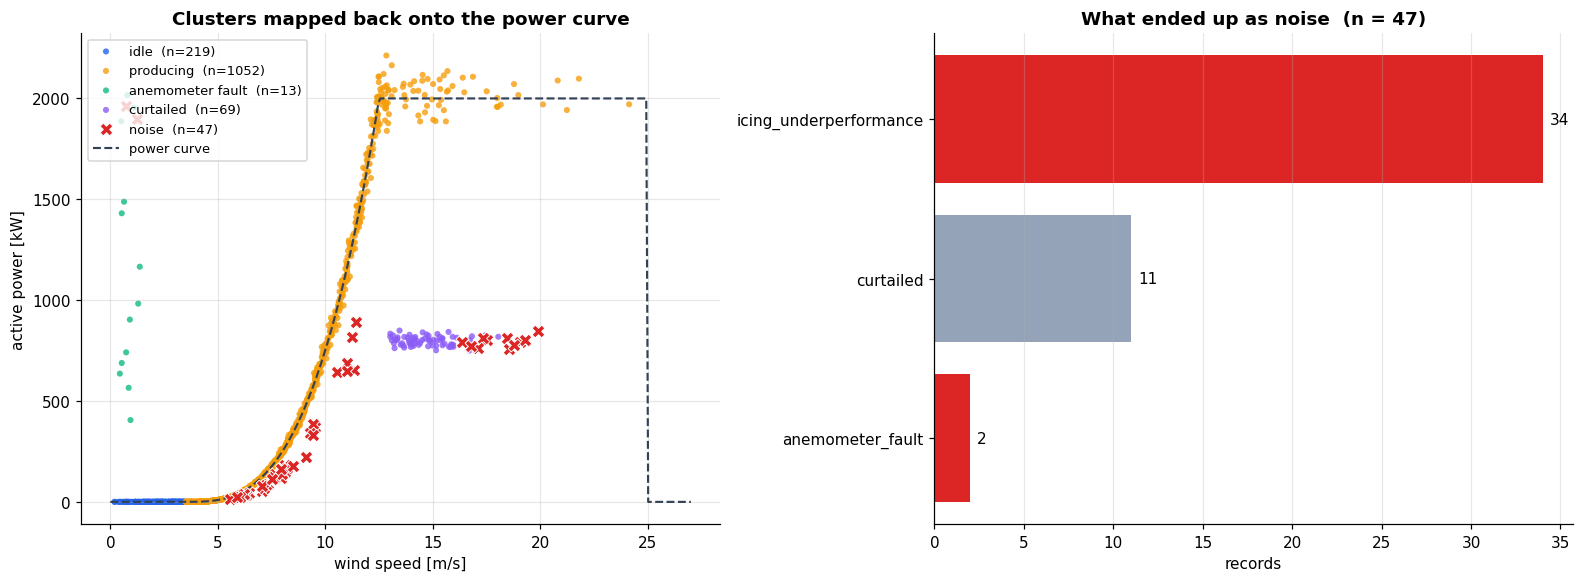

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))
names = {k: describe(summary.loc[k]).split(" - ")[0].lower()
         for k in sorted(set(labels) - {-1})}

ax = axes[0]
for k in sorted(set(labels) - {-1}):
    s = labels == k
    ax.scatter(df.wind_speed_ms[s], df.active_power_kw[s], s=16,
               c=PALETTE[k % len(PALETTE)], ec="none", alpha=.8,
               label=f"{names.get(k, k)}  (n={s.sum()})")
s = labels == -1
ax.scatter(df.wind_speed_ms[s], df.active_power_kw[s], s=70, c=NOISE_C, marker="X",
           ec="white", lw=.6, zorder=5, label=f"noise  (n={s.sum()})")
ax.plot(vv := np.linspace(0, 27, 300), ideal_power(vv), color="#334155", lw=1.4, ls="--",
        label="power curve")
ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel("active power [kW]")
ax.set_title("Clusters mapped back onto the power curve", fontweight="bold")
ax.legend(fontsize=8.5, loc="upper left")

ax = axes[1]
flagged = df[labels == -1].true_state.value_counts()
ax.barh(flagged.index[::-1], flagged.values[::-1],
        color=[NOISE_C if s in ("icing_underperformance", "anemometer_fault") else "#94a3b8"
               for s in flagged.index[::-1]])
for i, val in enumerate(flagged.values[::-1]):
    ax.text(val + 0.4, i, str(val), va="center", fontsize=10)
ax.set_title(f"What ended up as noise  (n = {int((labels == -1).sum())})", fontweight="bold")
ax.set_xlabel("records"); ax.grid(axis="y")
fig.tight_layout(); plt.show()

Two results here deserve separate attention.

**Curtailment became its own cluster.** Nobody told the algorithm that grid curtailment
exists. It appeared as a compact group of 69 records — capped power, pitch held high — and
DBSCAN named it a mode rather than an anomaly, which is exactly right: those hours are not a
turbine problem, and alarming on them would waste an engineer's week. A naive
deviation-from-curve alarm would have flagged all 80.

**The anemometer fault also became a cluster**, of 13 records. That is not a failure of the
method either — it is the main lecture's point about ε and MinPts arriving in practice. A
fault that repeats consistently *is* a mode, and DBSCAN reports repeated faults as clusters
and one-off oddities as noise. The consequence for how you use the output is concrete:

> **Do not read only `labels_ == -1`.** Read the whole cluster inventory, and ask of every
> cluster: *do I have a name for this?* A cluster you cannot name is either an operating mode
> you did not know about, or a fault that has become routine. Both are worth a phone call.

The icing, by contrast, is genuinely scattered — every event a different severity at a
different wind speed — so all 34 records land in the noise set, where we want them.

## 5.1 Does the fix survive a bad reference curve?

One honest objection: we used the manufacturer's power curve, and we happen to know it is
correct because we generated the data with it. Real turbines drift, and the warranted curve
is measured under standard air density. What if the reference is wrong?

In [16]:
rows = []
for bias in [-0.10, -0.05, 0.0, 0.05, 0.10]:
    p_b = ideal_power(v) * (1 + bias)                      # reference curve off by +-10 %
    Xb = StandardScaler().fit_transform(np.column_stack([
        np.clip((p_b - df.active_power_kw.values) / np.maximum(p_b, 100), -3, 1.2),
        np.clip(df.rotor_rpm.values / np.maximum(r_ref, 1.0), 0, 3),
        df.pitch_angle_deg.values - pi_ref]))
    lb = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(Xb)
    fl = lb == -1
    rows.append({"reference bias": f"{bias:+.0%}", "clusters": len(set(lb) - {-1}),
                 "flagged": int(fl.sum()),
                 "icing_recall": round(float(fl[df.true_state.values == "icing_underperformance"].mean()), 2),
                 "healthy_flagged": int((fl & ~faulty).sum())})
pd.DataFrame(rows).set_index("reference bias")

,clusters,flagged,icing_recall,healthy_flagged
reference bias,,,,
-10%,4,53,1.0,17
-5%,4,48,1.0,12
+0%,4,47,1.0,11
+5%,4,47,1.0,11
+10%,4,47,1.0,11


The method is strikingly tolerant: even a reference curve wrong by **±10 %** recovers all four
modes and keeps icing recall at 1.00, costing only a few extra false alarms on the pessimistic
side. A systematic bias shifts every residual together, which moves the
whole "normal" cluster rather than dispersing it — and DBSCAN does not care where a cluster
sits, only that it is dense. That robustness is a genuine advantage of clustering residuals
over thresholding them.

In practice you would learn the reference curve from the data itself (a binned median of
power against wind speed) rather than trusting the datasheet. Exercise 3 asks you to try it,
and to discover the trap: in the sparse high-wind bins the curtailed records can *outnumber*
the normal ones, so the learned median follows the curtailment and the fault disappears into
the reference. Robust statistics do not save you when the contamination is locally in the
majority.

---
# 6. Summary

1. **Varying density is a real limitation, not a footnote.** On a Weibull-distributed wind
   resource the local density falls by ~10× along the power curve, and no single ε works: you
   choose between missing most of the icing and flagging dozens of healthy high-wind records.
2. **Diagnose it by measuring, not guessing.** Plot the median k-NN distance against the
   variable you suspect. A gradient of 10× is decisive, and takes four lines.
3. **HDBSCAN did not rescue it.** At a matched alarm budget it caught slightly fewer icing
   events than DBSCAN. It removes the single-ε constraint, but the single-ε constraint was not
   the real problem: the healthy data is a *curve*, and density clustering needs *blobs*.
4. **The fix is a change of feature space, not of algorithm.** Dividing out the deterministic
   physics — expressing every record as a deviation from what the power curve predicts —
   flattens the density and turns the problem into the easy case from the main lecture. Plain
   DBSCAN then achieves silhouette 0.94, full icing recall, and 11 false alarms out of 1351
   healthy records — against 22–67 in §2 while missing most of the icing.
5. **Read the cluster inventory, not just the noise.** Curtailment and the anemometer fault
   both appeared as clusters. Repeated faults become modes; only sporadic ones stay noise.
6. The general principle: **when a density method struggles, ask what deterministic structure
   is still in your features.** Density clustering wants blobs. Your job is to hand it a space
   in which the thing you care about *is* a blob.

---
# 7. Exercises

1. **Move the site.** Change the Weibull scale from 8.6 to 11.0 (a windier site). Does the
   density gradient get better or worse? Does the §2 failure change character?
2. **Air density.** Real power curves shift with air density $\rho$. Add a seasonal
   $\rho$ variation of ±6 % to the generator, and correct for it in the reference
   (`ideal_power(v) * rho/rho_0`). How much icing recall do you lose if you *don't* correct?
3. **Learn the reference curve.** Replace `ideal_power` with a binned median of the observed
   power against wind speed. Confirm the trap described in §5.1 — inspect the learned curve
   above 13 m/s and explain what happened to the curtailed records.
4. **Curtailment as a fault.** Suppose the operator wants curtailment flagged after all
   (for billing). Which parameter would you change to turn cluster 3 back into noise, and what
   does that cost you elsewhere?
5. **OPTICS.** Run `OPTICS(min_samples=10)` on the raw channels and plot its reachability
   diagram. Can you read the varying density directly off that plot?
6. **Trend it.** Bin the records by `day` into fortnights and plot the fraction labelled noise.
   Does the icing appear as a season? Design an alarm rule and state its false-alarm rate.
7. **A gearbox channel.** Add `gearbox_oil_temp_C`, normally a function of power output, and
   inject a cooling fault where temperature is high for the power produced. Which space finds
   it — raw or residual? Why?

### References

- Ester, Kriegel, Sander & Xu, *A Density-Based Algorithm for Discovering Clusters…*, KDD-96.
- Campello, Moulavi & Sander, *Density-Based Clustering Based on Hierarchical Density
  Estimates*, PAKDD 2013 — the HDBSCAN algorithm.
- Ankerst, Breunig, Kriegel & Sander, *OPTICS: Ordering Points To Identify the Clustering
  Structure*, SIGMOD 1999.
- IEC 61400-12-1 — power performance measurement of electricity-producing wind turbines
  (the standard behind binned power curves and air-density correction).

Generated by Claude and customized by

<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2026</div>